In [2]:
# PCA

In [5]:
# Step 1: Import required libraries

#TODO:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_wine, load_breast_cancer, load_iris

In [6]:
# Step 2: Load the dataset for this batch

# TODO:
# Keep one option active.

# OPTION A: Wine dataset
# data = load_wine()
# X = pd.DataFrame(data.data, columns=data.feature_names)
# y = pd.Series(data.target, name="target")

# OPTION B: Breast Cancer dataset
# data = load_breast_cancer()
# X = pd.DataFrame(data.data, columns=data.feature_names)
# y = pd.Series(data.target, name="target")

# OPTION C: Custom CSV
# df = pd.read_csv("batch_b_pca_dataset.csv")
# X = df.drop(columns=["target"])
# y = df["target"]

# print("Feature shape:", X.shape)
# X.head()

iris = load_iris()

x=iris.data
y=iris.target

feature_names = iris. feature_names
target_name = iris.target_names

print("original data shape:", x.shape)

original data shape: (150, 4)


<Figure size 600x400 with 0 Axes>

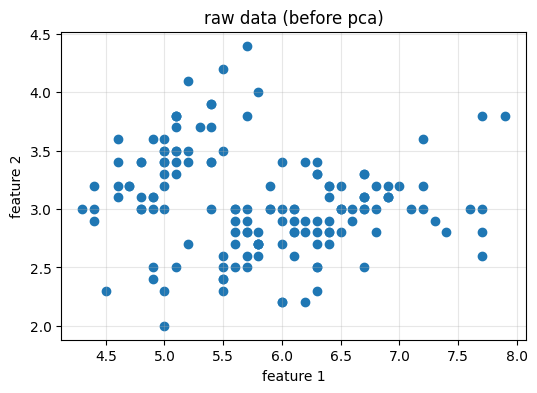

In [7]:
#Optional - Visualizing the data (Extra)
plt.figure(figsize=(6, 4))
plt.figure(figsize=(6, 4))

plt.scatter(x[:, 0], x[:, 1])

plt.title('raw data (before pca)')
plt.xlabel('feature 1')
plt.ylabel('feature 2')

plt.grid(alpha=0.3)
plt.show()

In [8]:
# Step 3: Standardize the data

# TODO:
# scaler = ...
# X_scaled = ...

# PCA is affected by scale, so standardization is important
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

#Converted the array data to dataframe
df = pd.DataFrame(x_scaled, columns = feature_names)
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444
5,-0.537178,1.939791,-1.169714,-1.052180
6,-1.506521,0.788808,-1.340227,-1.183812
7,-1.021849,0.788808,-1.283389,-1.315444
8,-1.748856,-0.362176,-1.340227,-1.315444
9,-1.143017,0.098217,-1.283389,-1.447076


In [10]:
# Step 4: Apply PCA using all components

# TODO:
# pca_full = ...
# X_pca_full =
# explained_var
# cumulative_var = ...
# print(explained_var)
# print(cumulative_var)

# Initialize PCA to keep all components (4 for the Iris dataset)
pca_full = PCA()

# Fit and transform the scaled data
X_pca_full = pca_full.fit_transform(x_scaled)

# Get the variance explained by each individual component
explained_var = pca_full.explained_variance_ratio_

# Calculate the cumulative variance explained
cumulative_var = np.cumsum(explained_var)

# Display the results
print("Explained Variance Ratio per component:")
print(explained_var)

print("\nCumulative Explained Variance:")
print(cumulative_var)

Explained Variance Ratio per component:
[0.72962445 0.22850762 0.03668922 0.00517871]

Cumulative Explained Variance:
[0.72962445 0.95813207 0.99482129 1.        ]


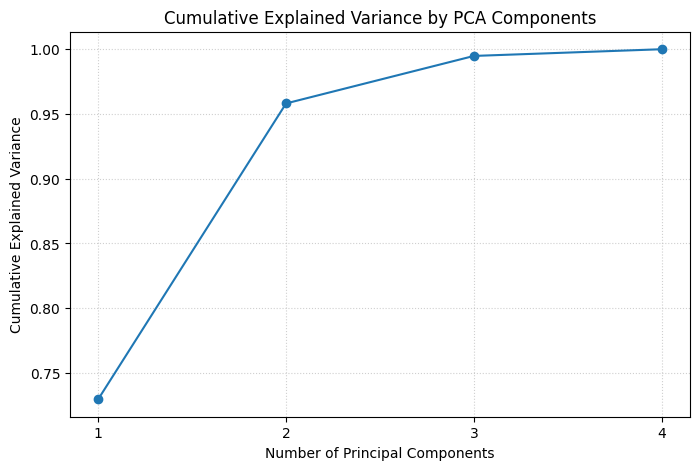

In [12]:
# Step 5: Plot cumulative explained variance

# TODO:
# Create a line plot of cumulative explained variance
# Add Labels, title, marker, and grid

plt.figure(figsize=(8, 5))
#Plotting the cumulative variance against the number of components
#We use np.arange(1, Len(cumulative_var) + 1) to Label components 1, 2, 3, 4
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o', linestyle='-')

# Adding Labels and title
plt.title('Cumulative Explained Variance by PCA Components' )
plt.xlabel('Number of Principal Components' )
plt.ylabel('Cumulative Explained Variance' )

# Adding a grid for better readability
plt.grid(True, linestyle=':', alpha=0.6)

# Setting x-ticks to show whole numbers only
plt.xticks(range(1, len(cumulative_var) +1))

plt.show()

In [14]:
# Step 6: Reduce data to two principal components

# TODO:
# pca_2
# X_pca_2 = ..
# print(X_pca_2.shape)
# print("Variance captured:", ... )
#
# Initialize PCA with n_components=2
pca_2 = PCA(n_components=2)

# Fit and transform the scaled data to reduce dimensions
X_pca_2 = pca_2.fit_transform(x_scaled)

# Calculate the total variance captured by these two components
variance_captured = np.sum(pca_2.explained_variance_ratio_)

# Display results
print("Shape of reduced data:", X_pca_2.shape)
print(f"Variance captured by 2 components: {variance_captured:.2%}")

Shape of reduced data: (150, 2)
Variance captured by 2 components: 95.81%


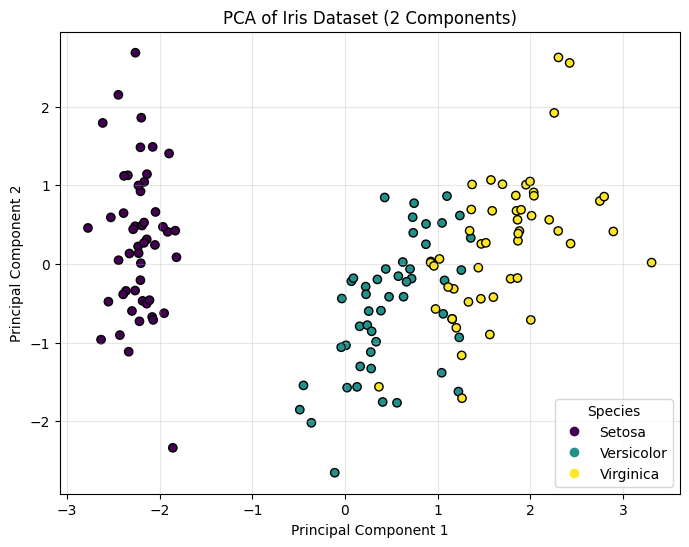

In [17]:
# Step 7: Plot the PCA-transformed data

# TODO:
# Create a scatter plot of PC1 vs PC2
# Use target labels as colors
# Add axis labels and title

plt.figure(figsize=(8,6))

# Create a scatter plot using the two principal components
# x-axis: first component (PC1), y-axis: second component (PC2)
scatter = plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=y, cmap='viridis', edgecolors='k')

# Add title and Labels
plt.title('PCA of Iris Dataset (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Create a legend for the species
handles, _ = scatter.legend_elements ()
target_names = ['Setosa', 'Versicolor', 'Virginica']
plt.legend(handles, target_names, title="Species")

plt.grid(alpha=0.3)
plt.show()

In [19]:
# Step 8: Optional feature contribution analysis

# TODO:
# Create a DataFrame using pca_2.components_.T
# Use original feature names as index
# Identify the features contributing strongly to PC1 and PC2
# Print the top positive / negative contributors
#----
# Extract loadings (weights) for each feature per component
# These are stored in pca_2.components_
loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_names
)

print("PCA Component Loadings:")
print(loadings)

# Identify the strongest contributors
print("\nTop contributors for PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False))

print("\nTop contributors for PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False))

PCA Component Loadings:
                        PC1       PC2
sepal length (cm)  0.521066  0.377418
sepal width (cm)  -0.269347  0.923296
petal length (cm)  0.580413  0.024492
petal width (cm)   0.564857  0.066942

Top contributors for PC1:
petal length (cm)    0.580413
petal width (cm)     0.564857
sepal length (cm)    0.521066
sepal width (cm)     0.269347
Name: PC1, dtype: float64

Top contributors for PC2:
sepal width (cm)     0.923296
sepal length (cm)    0.377418
petal width (cm)     0.066942
petal length (cm)    0.024492
Name: PC2, dtype: float64


In [ ]:
## Student Observation Section

#   1)How much total variance is retained by the first two principal components?
#   Ans: The first two principal components retain ~95.8% of total variance 
#        (PC1: 72.9%, PC2: 22.9%), indicating minimal information loss.

#   2)Which features contribute strongly to PC1 and PC2?
#   Ans:PC1 is influenced by petal length, petal width, and sepal length (overall size).
#       PC2 is mainly influenced by sepal width.

#   3)Is class separation visible after projection?
#   Ans: Yes, classes are clearly separated, especially Setosa.
#        PC1 contributes most to the separation.

#   4)Why is PCA usually applied after standardization?
#   Ans: Ensures equal feature contribution
#        Reduces dimensions
#        Helps visualization
#        Removes noise and correlation